RSR  not-supportive 92.0%  79-100   (23/25)
RSR  supportive     30.4%  14-48   (7/23)
drop 61.6 pts [42, 81]


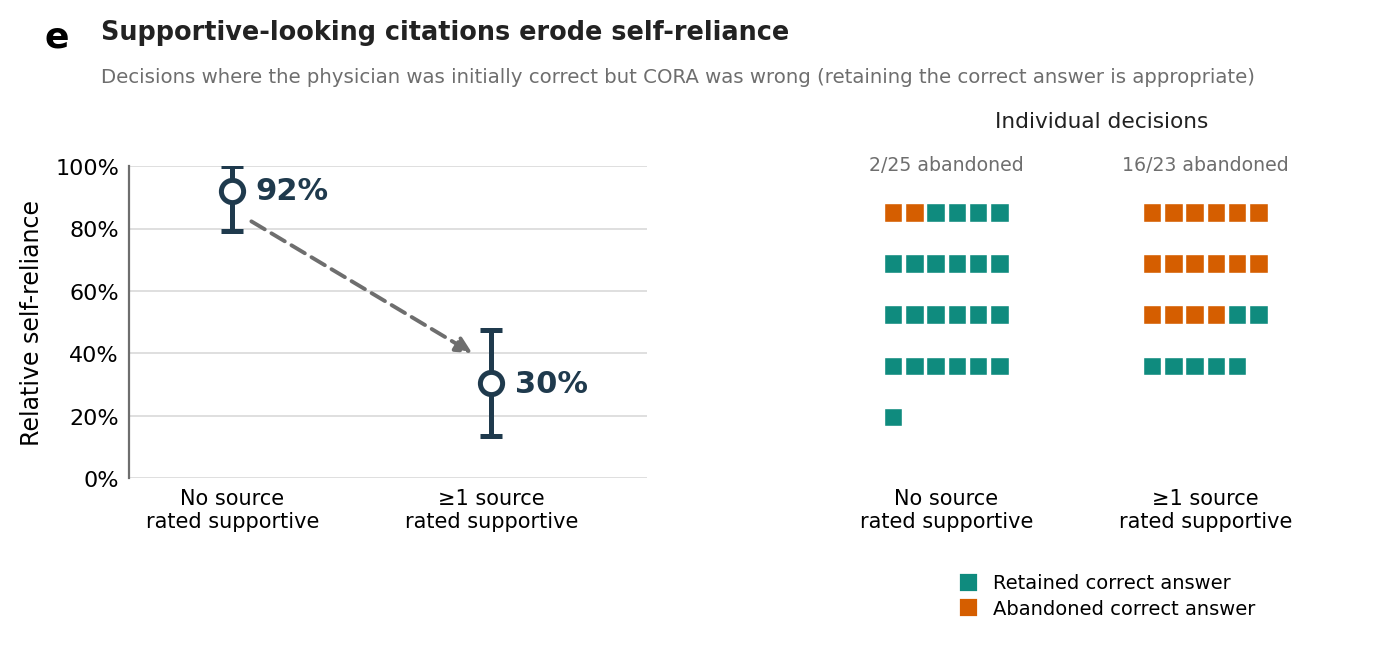

In [30]:
# ── Fig 3e: RSR drop by citation support ────────────────────────────────────
# Domain: physician initially CORRECT and CORA/LLM WRONG (self-reliance is the
# appropriate response). RSR = P(retain correct final answer | initial correct
# & LLM wrong), split by whether >=1 CORA source was rated supportive.
# Layout: estimate + CI (left) beside one icon per decision (right).
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

CSV = "../results/reader_study/responses.csv"          # <-- edit path
SUPPORT_COL = "any_source_supports"   # or "all_sources_support" (see note below)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",   # editable text in Illustrator/Inkscape
    "axes.linewidth": 0.8, "font.size": 8,
})
C_RET, C_FAIL = "#0F8B7E", "#D55E00"          # teal = retained (good), vermillion = abandoned (harm)
C_GRID, C_TXT, C_MUT = "#D9D9D9", "#222222", "#6E6E6E"
C_INK = "#1F3A4D"

# ── data & domain ────────────────────────────────────────────────────────────
r = pd.read_csv(CSV)
d = r[r.answered]
sr = d[(d.initial_correct) & (~d.llm_is_correct)].copy()   # RSR domain
sr["sup"] = sr[SUPPORT_COL]

ns_out = sr.loc[~sr.sup, "final_correct"].values.astype(bool)   # citations NOT supportive
s_out  = sr.loc[ sr.sup, "final_correct"].values.astype(bool)   # >=1 supportive
a, b = ns_out.sum(), (~ns_out).sum()   # not-sup: retained, abandoned
c, e = s_out.sum(),  (~s_out).sum()    # sup:     retained, abandoned
rsr_ns, rsr_s = a/(a+b), c/(c+e)

# ── inference: physician-clustered bootstrap ─────────────────────────────────
def clustered_bootstrap(dom, B=10000, seed=42):
    """Resample physicians (clusters) with replacement; return RSR in each stratum."""
    rng = np.random.default_rng(seed)
    sup = dom.sup.values
    ret = dom.final_correct.values.astype(float)
    codes, uniq = pd.factorize(dom.pid)
    by = [np.where(codes == i)[0] for i in range(len(uniq))]
    n = len(uniq)
    d_ns, d_s = [], []
    for _ in range(B):
        idx = np.concatenate([by[i] for i in rng.integers(0, n, n)])
        sv, rv = sup[idx], ret[idx]
        if sv.sum() == 0 or (~sv).sum() == 0:      # skip resamples missing a stratum
            continue
        d_ns.append(rv[~sv].mean()); d_s.append(rv[sv].mean())
    return np.array(d_ns), np.array(d_s)

d_ns, d_s = clustered_bootstrap(sr)
ci_ns  = (np.percentile(d_ns, 2.5), np.percentile(d_ns, 97.5))
ci_s   = (np.percentile(d_s, 2.5),  np.percentile(d_s, 97.5))
diff   = d_ns - d_s
ci_dif = (np.percentile(diff, 2.5), np.percentile(diff, 97.5))

# ── figure: estimate (left) beside one icon per decision (right) ─────────────
XL = ["No source\nrated supportive", "≥1 source\nrated supportive"]

fig = plt.figure(figsize=(7.0, 3.0), dpi=200)     # ~180 mm double-column
axL = fig.add_axes([0.075, 0.20, 0.37, 0.52])     # left:  estimate + CI
axR = fig.add_axes([0.585, 0.20, 0.37, 0.52])     # right: icon array

# ── left panel: estimate + CI ────────────────────────────────────────────────
def est(x0, rsr, ci, col):
    axL.errorbar(x0, rsr*100, yerr=[[(rsr-ci[0])*100], [(ci[1]-rsr)*100]],
                 fmt="o", ms=8, mfc="white", mec=col, mew=1.8,
                 ecolor=col, elinewidth=1.8, capsize=4, capthick=1.8, zorder=5)
    axL.text(x0 + 0.09, rsr*100, f"{rsr*100:.0f}%", va="center", ha="left",
             fontsize=11, fontweight="bold", color=col)

est(0, rsr_ns, ci_ns, C_INK)
est(1, rsr_s,  ci_s,  C_INK)

axL.add_patch(FancyArrowPatch((0, rsr_ns*100-6), (1, rsr_s*100+6),
              arrowstyle="-|>", mutation_scale=12, lw=1.4, color=C_MUT,
              ls=(0, (4, 2)), zorder=2, shrinkA=8, shrinkB=8))

axL.set_ylim(0, 100); axL.set_xlim(-0.4, 1.6)
axL.set_yticks(range(0, 101, 20)); axL.set_yticklabels([f"{v}%" for v in range(0, 101, 20)])
axL.set_ylabel("Relative self-reliance", fontsize=8.5)
for y in range(0, 101, 20): axL.axhline(y, color=C_GRID, lw=0.6, zorder=0)
axL.set_xticks([0, 1]); axL.set_xticklabels(XL, fontsize=7.5); axL.tick_params(length=0)
for s in ("top", "right", "bottom"): axL.spines[s].set_visible(False)
axL.spines["left"].set_color(C_MUT)

# ── right panel: one icon per decision ───────────────────────────────────────
NCOL = 6
def draw_array(x0, outcomes):
    out = np.sort(outcomes)                       # abandoned (False) first -> bottom rows
    xs, ys, cols = [], [], []
    for i, ret in enumerate(out):
        col, row = i % NCOL, i // NCOL
        xs.append(x0 - 0.205 + col * 0.082); ys.append(row)
        cols.append(C_RET if ret else C_FAIL)
    axR.scatter(xs, ys, s=44, c=cols, marker="s", edgecolors="white",
                linewidths=0.5, zorder=3, clip_on=False)
    return int(np.ceil(len(out) / NCOL))

rmax = max(draw_array(0, ns_out), draw_array(1, s_out))
axR.set_xlim(-0.4, 1.6); axR.set_ylim(-0.9, rmax + 0.2); axR.invert_yaxis()
axR.set_xticks([0, 1]); axR.set_xticklabels(XL, fontsize=7.5); axR.tick_params(length=0)
axR.set_yticks([])
for s in ("top", "right", "left", "bottom"): axR.spines[s].set_visible(False)
axR.text(0, -0.75, f"{b}/{a+b} abandoned", ha="center", va="bottom", fontsize=6.8, color=C_MUT)
axR.text(1, -0.75, f"{e}/{c+e} abandoned", ha="center", va="bottom", fontsize=6.8, color=C_MUT)
axR.set_title("Individual decisions", fontsize=7.8, color=C_TXT, pad=14)

# legend belongs to the icon panel (below it)
lh = [plt.Line2D([0], [0], marker="s", ls="", mfc=C_RET, mec="white", ms=7.5, label="Retained correct answer"),
      plt.Line2D([0], [0], marker="s", ls="", mfc=C_FAIL, mec="white", ms=7.5, label="Abandoned correct answer")]
axR.legend(handles=lh, loc="upper center", bbox_to_anchor=(0.5, -0.28),
           frameon=False, fontsize=7, handletextpad=0.3, ncol=1,
           labelspacing=0.35, borderaxespad=0)

# ── header ───────────────────────────────────────────────────────────────────
fig.text(0.015, 0.965, "e", fontsize=13, fontweight="bold", va="top")
fig.text(0.055, 0.965, "Supportive-looking citations erode self-reliance",
         fontsize=9.2, fontweight="bold", va="top", color=C_TXT)
fig.text(0.055, 0.885,
         "Decisions where the physician was initially correct but CORA was wrong "
         "(retaining the correct answer is appropriate)",
         fontsize=7.1, va="top", color=C_MUT)

print(f"RSR  not-supportive {rsr_ns*100:.1f}%  {ci_ns[0]*100:.0f}-{ci_ns[1]*100:.0f}   ({a}/{a+b})")
print(f"RSR  supportive     {rsr_s*100:.1f}%  {ci_s[0]*100:.0f}-{ci_s[1]*100:.0f}   ({c}/{c+e})")
print(f"drop {(rsr_ns-rsr_s)*100:.1f} pts [{ci_dif[0]*100:.0f}, {ci_dif[1]*100:.0f}]")

#fig.savefig("Fig3e_RSR_by_citation_support.pdf", bbox_inches="tight", facecolor="white")
plt.show()

RSR  not-supportive 92.0%  79-100   (23/25)
RSR  supportive     30.4%  14-48   (7/23)
drop 61.6 pts [42, 81]


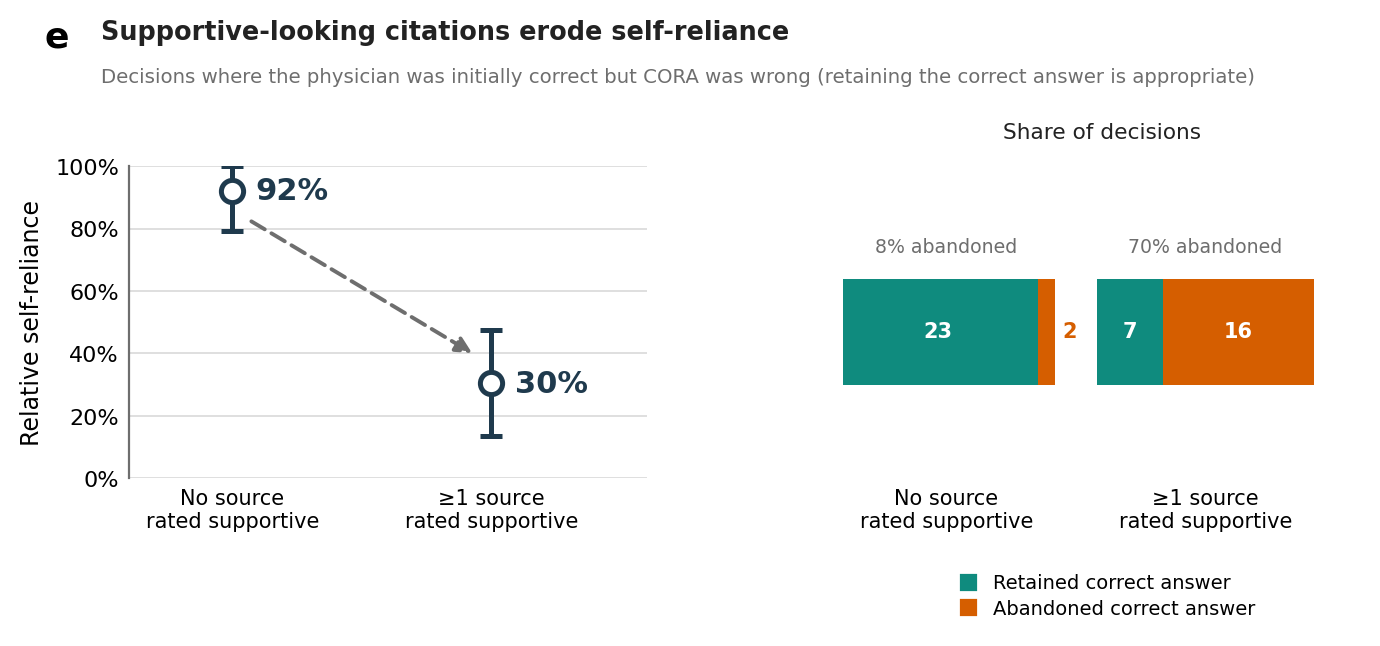

In [31]:
# ── Fig 3e (variant): RSR estimate + horizontal stacked bars ─────────────────
# Same domain as above; the icon array is replaced by a horizontal 100%-stacked
# bar per bucket, placed just above each bucket's x label.
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

CSV = "../results/reader_study/responses.csv"          # <-- edit path
SUPPORT_COL = "any_source_supports"   # or "all_sources_support"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "axes.linewidth": 0.8, "font.size": 8,
})
C_RET, C_FAIL = "#0F8B7E", "#D55E00"
C_GRID, C_TXT, C_MUT = "#D9D9D9", "#222222", "#6E6E6E"
C_INK = "#1F3A4D"

# ── data & domain ────────────────────────────────────────────────────────────
r = pd.read_csv(CSV)
d = r[r.answered]
sr = d[(d.initial_correct) & (~d.llm_is_correct)].copy()
sr["sup"] = sr[SUPPORT_COL]

ns_out = sr.loc[~sr.sup, "final_correct"].values.astype(bool)
s_out  = sr.loc[ sr.sup, "final_correct"].values.astype(bool)
a, b = ns_out.sum(), (~ns_out).sum()   # not-sup: retained, abandoned
c, e = s_out.sum(),  (~s_out).sum()    # sup:     retained, abandoned
rsr_ns, rsr_s = a/(a+b), c/(c+e)

# ── inference: physician-clustered bootstrap ─────────────────────────────────
def clustered_bootstrap(dom, B=10000, seed=42):
    rng = np.random.default_rng(seed)
    sup = dom.sup.values
    ret = dom.final_correct.values.astype(float)
    codes, uniq = pd.factorize(dom.pid)
    by = [np.where(codes == i)[0] for i in range(len(uniq))]
    n = len(uniq)
    d_ns, d_s = [], []
    for _ in range(B):
        idx = np.concatenate([by[i] for i in rng.integers(0, n, n)])
        sv, rv = sup[idx], ret[idx]
        if sv.sum() == 0 or (~sv).sum() == 0:
            continue
        d_ns.append(rv[~sv].mean()); d_s.append(rv[sv].mean())
    return np.array(d_ns), np.array(d_s)

d_ns, d_s = clustered_bootstrap(sr)
ci_ns  = (np.percentile(d_ns, 2.5), np.percentile(d_ns, 97.5))
ci_s   = (np.percentile(d_s, 2.5),  np.percentile(d_s, 97.5))
diff   = d_ns - d_s
ci_dif = (np.percentile(diff, 2.5), np.percentile(diff, 97.5))

# ── figure: estimate (left) beside stacked bars (right) ──────────────────────
XL = ["No source\nrated supportive", "≥1 source\nrated supportive"]

fig = plt.figure(figsize=(7.0, 3.0), dpi=200)
axL = fig.add_axes([0.075, 0.20, 0.37, 0.52])     # left:  estimate + CI
axR = fig.add_axes([0.585, 0.20, 0.37, 0.52])     # right: stacked bars

# ── left panel: estimate + CI ────────────────────────────────────────────────
def est(x0, rsr, ci, col):
    axL.errorbar(x0, rsr*100, yerr=[[(rsr-ci[0])*100], [(ci[1]-rsr)*100]],
                 fmt="o", ms=8, mfc="white", mec=col, mew=1.8,
                 ecolor=col, elinewidth=1.8, capsize=4, capthick=1.8, zorder=5)
    axL.text(x0 + 0.09, rsr*100, f"{rsr*100:.0f}%", va="center", ha="left",
             fontsize=11, fontweight="bold", color=col)

est(0, rsr_ns, ci_ns, C_INK)
est(1, rsr_s,  ci_s,  C_INK)

axL.add_patch(FancyArrowPatch((0, rsr_ns*100-6), (1, rsr_s*100+6),
              arrowstyle="-|>", mutation_scale=12, lw=1.4, color=C_MUT,
              ls=(0, (4, 2)), zorder=2, shrinkA=8, shrinkB=8))

axL.set_ylim(0, 100); axL.set_xlim(-0.4, 1.6)
axL.set_yticks(range(0, 101, 20)); axL.set_yticklabels([f"{v}%" for v in range(0, 101, 20)])
axL.set_ylabel("Relative self-reliance", fontsize=8.5)
for y in range(0, 101, 20): axL.axhline(y, color=C_GRID, lw=0.6, zorder=0)
axL.set_xticks([0, 1]); axL.set_xticklabels(XL, fontsize=7.5); axL.tick_params(length=0)
for s in ("top", "right", "bottom"): axL.spines[s].set_visible(False)
axL.spines["left"].set_color(C_MUT)

# ── right panel: horizontal 100%-stacked bar per bucket, above its label ─────
HALF = 0.42          # half-width of each bar (data units) -> spans 100%
Y0, BH = 0.30, 0.34  # bar bottom and height within ylim(0, 1)
def stacked_bar(x0, ret, ab, tot):
    fr = ret / tot; L = x0 - HALF; R = x0 + HALF; wret = fr * 2 * HALF; cy = Y0 + BH/2
    axR.barh(cy, wret, left=L, height=BH, color=C_RET, zorder=3, align="center")
    axR.barh(cy, 2*HALF - wret, left=L + wret, height=BH, color=C_FAIL, zorder=3, align="center")
    # retained count: white inside if the segment is wide enough, else just left of the bar
    if fr >= 0.16:
        axR.text(L + wret/2, cy, f"{ret}", ha="center", va="center",
                 fontsize=7.5, color="white", fontweight="bold")
    else:
        axR.text(L - 0.03, cy, f"{ret}", ha="right", va="center",
                 fontsize=7.5, color=C_RET, fontweight="bold")
    # abandoned count: white inside if wide enough, else just right of the bar
    if (1 - fr) >= 0.16:
        axR.text(L + wret + (2*HALF - wret)/2, cy, f"{ab}", ha="center", va="center",
                 fontsize=7.5, color="white", fontweight="bold")
    else:
        axR.text(R + 0.03, cy, f"{ab}", ha="left", va="center",
                 fontsize=7.5, color=C_FAIL, fontweight="bold")
    axR.text(x0, Y0 + BH + 0.07, f"{ab/tot*100:.0f}% abandoned", ha="center", va="bottom",
             fontsize=6.8, color=C_MUT)

stacked_bar(0, a, b, a+b)
stacked_bar(1, c, e, c+e)
axR.set_xlim(-0.4, 1.6); axR.set_ylim(0, 1)
axR.set_xticks([0, 1]); axR.set_xticklabels(XL, fontsize=7.5); axR.tick_params(length=0)
axR.set_yticks([])
for s in ("top", "right", "left", "bottom"): axR.spines[s].set_visible(False)
axR.set_title("Share of decisions", fontsize=7.8, color=C_TXT, pad=10)

# legend belongs to the bars panel (below it)
lh = [plt.Line2D([0], [0], marker="s", ls="", mfc=C_RET, mec="white", ms=7.5, label="Retained correct answer"),
      plt.Line2D([0], [0], marker="s", ls="", mfc=C_FAIL, mec="white", ms=7.5, label="Abandoned correct answer")]
axR.legend(handles=lh, loc="upper center", bbox_to_anchor=(0.5, -0.28),
           frameon=False, fontsize=7, handletextpad=0.3, ncol=1,
           labelspacing=0.35, borderaxespad=0)

# ── header ───────────────────────────────────────────────────────────────────
fig.text(0.015, 0.965, "e", fontsize=13, fontweight="bold", va="top")
fig.text(0.055, 0.965, "Supportive-looking citations erode self-reliance",
         fontsize=9.2, fontweight="bold", va="top", color=C_TXT)
fig.text(0.055, 0.885,
         "Decisions where the physician was initially correct but CORA was wrong "
         "(retaining the correct answer is appropriate)",
         fontsize=7.1, va="top", color=C_MUT)

print(f"RSR  not-supportive {rsr_ns*100:.1f}%  {ci_ns[0]*100:.0f}-{ci_ns[1]*100:.0f}   ({a}/{a+b})")
print(f"RSR  supportive     {rsr_s*100:.1f}%  {ci_s[0]*100:.0f}-{ci_s[1]*100:.0f}   ({c}/{c+e})")
print(f"drop {(rsr_ns-rsr_s)*100:.1f} pts [{ci_dif[0]*100:.0f}, {ci_dif[1]*100:.0f}]")

#fig.savefig("Fig3e_RSR_by_citation_support_bars.pdf", bbox_inches="tight", facecolor="white")
plt.show()

RSR  not-supportive 92.0%  79-100   (23/25)
RSR  supportive     30.4%  14-48   (7/23)
drop 61.6 pts [42, 81]


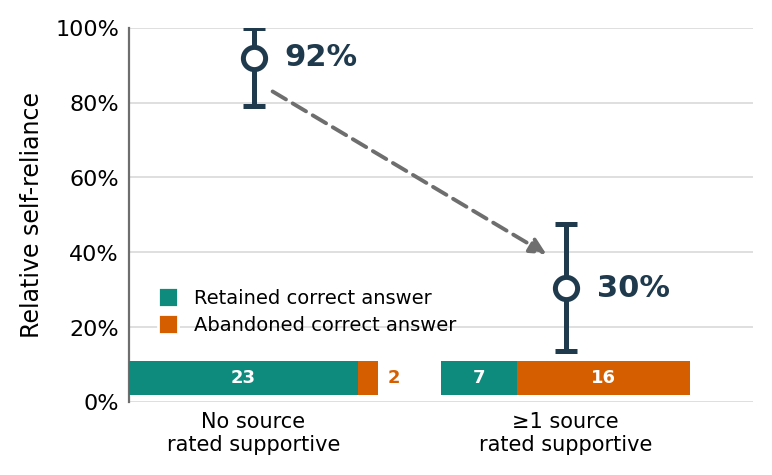

In [32]:
# ── Fig 3e (variant 2): single panel, stacked bars inside the RSR plot ───────
# Same domain; a horizontal 100%-stacked bar per bucket sits at the base of the
# RSR plot, just above each bucket's x label (retained teal / abandoned vermillion).
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

CSV = "../results/reader_study/responses.csv"          # <-- edit path
SUPPORT_COL = "any_source_supports"   # or "all_sources_support"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "axes.linewidth": 0.8, "font.size": 8,
})
C_RET, C_FAIL = "#0F8B7E", "#D55E00"
C_GRID, C_TXT, C_MUT = "#D9D9D9", "#222222", "#6E6E6E"
C_INK = "#1F3A4D"

# ── data & domain ────────────────────────────────────────────────────────────
r = pd.read_csv(CSV)
d = r[r.answered]
sr = d[(d.initial_correct) & (~d.llm_is_correct)].copy()
sr["sup"] = sr[SUPPORT_COL]

ns_out = sr.loc[~sr.sup, "final_correct"].values.astype(bool)
s_out  = sr.loc[ sr.sup, "final_correct"].values.astype(bool)
a, b = ns_out.sum(), (~ns_out).sum()   # not-sup: retained, abandoned
c, e = s_out.sum(),  (~s_out).sum()    # sup:     retained, abandoned
rsr_ns, rsr_s = a/(a+b), c/(c+e)

# ── inference: physician-clustered bootstrap ─────────────────────────────────
def clustered_bootstrap(dom, B=10000, seed=42):
    rng = np.random.default_rng(seed)
    sup = dom.sup.values
    ret = dom.final_correct.values.astype(float)
    codes, uniq = pd.factorize(dom.pid)
    by = [np.where(codes == i)[0] for i in range(len(uniq))]
    n = len(uniq)
    d_ns, d_s = [], []
    for _ in range(B):
        idx = np.concatenate([by[i] for i in rng.integers(0, n, n)])
        sv, rv = sup[idx], ret[idx]
        if sv.sum() == 0 or (~sv).sum() == 0:
            continue
        d_ns.append(rv[~sv].mean()); d_s.append(rv[sv].mean())
    return np.array(d_ns), np.array(d_s)

d_ns, d_s = clustered_bootstrap(sr)
ci_ns  = (np.percentile(d_ns, 2.5), np.percentile(d_ns, 97.5))
ci_s   = (np.percentile(d_s, 2.5),  np.percentile(d_s, 97.5))
diff   = d_ns - d_s
ci_dif = (np.percentile(diff, 2.5), np.percentile(diff, 97.5))

# ── figure: single panel ─────────────────────────────────────────────────────
XL = ["No source\nrated supportive", "≥1 source\nrated supportive"]

fig = plt.figure(figsize=(3.9, 3.6), dpi=200)     # ~99 mm single-column
ax = fig.add_axes([0.15, 0.235, 0.80, 0.52])

def est(x0, rsr, ci, col):
    ax.errorbar(x0, rsr*100, yerr=[[(rsr-ci[0])*100], [(ci[1]-rsr)*100]],
                fmt="o", ms=8, mfc="white", mec=col, mew=1.8,
                ecolor=col, elinewidth=1.8, capsize=4, capthick=1.8, zorder=6)
    ax.text(x0 + 0.10, rsr*100, f"{rsr*100:.0f}%", va="center", ha="left",
            fontsize=11, fontweight="bold", color=col)

est(0, rsr_ns, ci_ns, C_INK)
est(1, rsr_s,  ci_s,  C_INK)

ax.add_patch(FancyArrowPatch((0, rsr_ns*100-6), (1, rsr_s*100+6),
             arrowstyle="-|>", mutation_scale=12, lw=1.4, color=C_MUT,
             ls=(0, (4, 2)), zorder=2, shrinkA=8, shrinkB=8))

# ── in-plot stacked bar per bucket, just above the x labels ───────────────────
HALF = 0.40; YB, BH = 2.0, 9.0        # bar bottom & height on the 0-100 axis
def stacked_bar(x0, ret, ab, tot):
    fr = ret / tot; L = x0 - HALF; R = x0 + HALF; wret = fr * 2 * HALF; cy = YB + BH/2
    ax.barh(cy, wret, left=L, height=BH, color=C_RET, zorder=4, align="center")
    ax.barh(cy, 2*HALF - wret, left=L + wret, height=BH, color=C_FAIL, zorder=4, align="center")
    # retained count: white inside if the segment is wide enough, else just left of the bar
    if fr >= 0.16:
        ax.text(L + wret/2, cy, f"{ret}", ha="center", va="center",
                fontsize=6.5, color="white", fontweight="bold", zorder=5)
    else:
        ax.text(L - 0.03, cy, f"{ret}", ha="right", va="center",
                fontsize=6.5, color=C_RET, fontweight="bold", zorder=5)
    # abandoned count: white inside if wide enough, else just right of the bar
    if (1 - fr) >= 0.16:
        ax.text(L + wret + (2*HALF - wret)/2, cy, f"{ab}", ha="center", va="center",
                fontsize=6.5, color="white", fontweight="bold", zorder=5)
    else:
        ax.text(R + 0.03, cy, f"{ab}", ha="left", va="center",
                fontsize=6.5, color=C_FAIL, fontweight="bold", zorder=5)

stacked_bar(0, a, b, a+b)
stacked_bar(1, c, e, c+e)

ax.set_ylim(0, 100); ax.set_xlim(-0.4, 1.6)
ax.set_yticks(range(0, 101, 20)); ax.set_yticklabels([f"{v}%" for v in range(0, 101, 20)])
ax.set_ylabel("Relative self-reliance", fontsize=8.5)
for y in range(0, 101, 20): ax.axhline(y, color=C_GRID, lw=0.6, zorder=0)
ax.set_xticks([0, 1]); ax.set_xticklabels(XL, fontsize=7.5); ax.tick_params(length=0)
for s in ("top", "right", "bottom"): ax.spines[s].set_visible(False)
ax.spines["left"].set_color(C_MUT)

# ── header + legend ──────────────────────────────────────────────────────────
#fig.text(0.03, 0.965, "e", fontsize=13, fontweight="bold", va="top")
#fig.text(0.10, 0.965, "Supportive-looking citations erode self-reliance",
#         fontsize=9.0, fontweight="bold", va="top", color=C_TXT)
#fig.text(0.10, 0.905,
#         "Decisions where the physician was initially correct but CORA was wrong\n"
#         "(retaining the correct answer is the appropriate response)",
#         fontsize=7.0, va="top", color=C_MUT)
lh = [plt.Line2D([0], [0], marker="s", ls="", mfc=C_RET, mec="white", ms=7.5, label="Retained correct answer"),
      plt.Line2D([0], [0], marker="s", ls="", mfc=C_FAIL, mec="white", ms=7.5, label="Abandoned correct answer")]
ax.legend(handles=lh, loc="lower left", bbox_to_anchor=(0.02, 0.16),
          frameon=False, fontsize=7, handletextpad=0.3, ncol=1,
          labelspacing=0.4, borderaxespad=0)

print(f"RSR  not-supportive {rsr_ns*100:.1f}%  {ci_ns[0]*100:.0f}-{ci_ns[1]*100:.0f}   ({a}/{a+b})")
print(f"RSR  supportive     {rsr_s*100:.1f}%  {ci_s[0]*100:.0f}-{ci_s[1]*100:.0f}   ({c}/{c+e})")
print(f"drop {(rsr_ns-rsr_s)*100:.1f} pts [{ci_dif[0]*100:.0f}, {ci_dif[1]*100:.0f}]")

fig.savefig("../plots/reader_study/rsr_by_citation_support.png", bbox_inches="tight", facecolor="white")
plt.show()